In [1]:
import os
from utils.eda_utils import EDAUtils, FeatureEngineering, DataCleaningUtils
from utils.ml_utils_v2 import RegressionAnalysis
import joblib
import pandas as pd
from scipy.stats import skew
import numpy as np

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
eda_utils = EDAUtils()
dcu = DataCleaningUtils()
fe = FeatureEngineering()

In [4]:
SCRIPT_DIR_PATH = os.getcwd()
ROOT_DIR_PATH = os.path.dirname(SCRIPT_DIR_PATH)
DATA_DIR_PATH = os.path.join(ROOT_DIR_PATH, "data")
PROCESSED_DATA_DIR_PATH = os.path.join(DATA_DIR_PATH, "processed_data")
RESULTS_DIR_PATH = os.path.join(SCRIPT_DIR_PATH, "results")
OUTPUT_DIR_PATH = os.path.join(SCRIPT_DIR_PATH, "output")
ENSEMBLE_DIR_PATH = os.path.join(OUTPUT_DIR_PATH, "ensemble")
MODELS_DIR_PATH = os.path.join(OUTPUT_DIR_PATH, "models")
TRAINING_DIR_PATH = os.path.join(OUTPUT_DIR_PATH, "training")

# Make sure the output directories exist
os.makedirs(ENSEMBLE_DIR_PATH, exist_ok=True)
os.makedirs(MODELS_DIR_PATH, exist_ok=True)
os.makedirs(TRAINING_DIR_PATH, exist_ok=True)

## 1. Load Historical Emissions Data, World Bank Indicators Data, and Policy Data

In [5]:
# Load the emissions data
emissions_df = pd.read_csv(os.path.join(PROCESSED_DATA_DIR_PATH, "historical_total_emission_per_country.csv"))
# emissions_df = pd.read_csv(os.path.join(PROCESSED_DATA_DIR_PATH, "total_emissions_legacy.csv"))
emissions_df.head()

,iso_alpha_3,year,total_emissions
0,ABW,1970,0.036970
1,ABW,1971,0.041825
2,ABW,1972,0.052708
3,ABW,1973,0.057704
4,ABW,1974,0.056999


In [6]:
emissions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12375 entries, 0 to 12374
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   iso_alpha_3      12375 non-null  object 
 1   year             12375 non-null  int64  
 2   total_emissions  12375 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 290.2+ KB


In [7]:
# Check emissions max year
emissions_df['year'].max()

np.int64(2024)

In [8]:
# Load the wb indicators
wb_df = pd.read_csv(os.path.join(PROCESSED_DATA_DIR_PATH, "wb_indicators_filtered.csv"))
wb_df.head()

,iso_alpha_3,year,pop_growth,food_production_index,pop_total,exports_pct_of_gdp,renewable_energy_output_pct,energy_use_kg_of_oil_equivalent_per_capita,population_in_urban_agglomerations_over_1m_pct,gdp_per_capita_growth_pct,...,gdp_per_capita_2021_ppp_intl_usd,fertilizer_consumption_kg_per_ha_arable_land,crop_production_index,agricultural_land_pct,arable_land_pct,electricity_from_renewables_pct,renewable_energy_consumption_pct,forest_area_pct,gdp_growth_pct,manufacturing_pct_of_gdp
0,ALB,1980,2.047964,41.13,2671997.0,23.957492,NaN,NaN,NaN,NaN,...,NaN,160.170940,48.98,40.802920,21.350365,NaN,NaN,NaN,NaN,NaN
1,ALB,1981,2.002974,42.77,2726056.0,23.810507,NaN,NaN,NaN,3.648649,...,NaN,138.435374,50.89,40.729927,21.459854,NaN,NaN,NaN,5.745635,NaN
2,ALB,1982,2.113272,44.14,2784278.0,20.072918,NaN,NaN,NaN,0.795840,...,NaN,179.966044,53.23,40.656934,21.496350,NaN,NaN,NaN,2.948597,NaN
3,ALB,1983,2.120885,48.08,2843960.0,18.852075,NaN,NaN,NaN,-1.016802,...,NaN,174.363328,59.51,40.510949,21.496350,NaN,NaN,NaN,1.104938,NaN
4,ALB,1984,2.103937,44.62,2904429.0,18.040331,NaN,NaN,NaN,-3.307497,...,NaN,159.592530,54.66,40.620438,21.496350,NaN,NaN,NaN,-1.251597,NaN


In [9]:
wb_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7695 entries, 0 to 7694
Data columns (total 25 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   iso_alpha_3                                     7695 non-null   object 
 1   year                                            7695 non-null   int64  
 2   pop_growth                                      7693 non-null   float64
 3   food_production_index                           7014 non-null   float64
 4   pop_total                                       7695 non-null   float64
 5   exports_pct_of_gdp                              6461 non-null   float64
 6   renewable_energy_output_pct                     4962 non-null   float64
 7   energy_use_kg_of_oil_equivalent_per_capita      4823 non-null   float64
 8   population_in_urban_agglomerations_over_1m_pct  5265 non-null   float64
 9   gdp_per_capita_growth_pct                

In [10]:
# check wb data max year
wb_df['year'].max()

np.int64(2024)

In [11]:
# load the policy index data
policy_indices = pd.read_csv(os.path.join(PROCESSED_DATA_DIR_PATH, "IEA_policy_indices.csv"))
policy_indices.head()

,iso_alpha_3,year,policy_flow_raw_stock,policy_flow_jur_stock,policy_flow_jur_nlp_stock
0,AFG,1971,1,0.25,0.1875
1,AFG,1972,2,0.50,0.3750
2,AFG,1973,3,0.75,0.5625
3,AFG,1974,4,1.00,0.7500
4,AFG,1975,5,1.25,0.9375


In [12]:
policy_indices["year"].max()

np.int64(2030)

## Merge All Data

In [13]:
print("policy indices shape:", policy_indices.shape)
print("indicators shape:", wb_df.shape)
policies_and_indicators_df = pd.merge(policy_indices, wb_df, on=["iso_alpha_3", "year"], how="inner")
print("merged shape:", policies_and_indicators_df.shape)
policies_and_indicators_df.head()

policy indices shape: (9687, 5)
indicators shape: (7695, 25)
merged shape: (6454, 28)


,iso_alpha_3,year,policy_flow_raw_stock,policy_flow_jur_stock,policy_flow_jur_nlp_stock,pop_growth,food_production_index,pop_total,exports_pct_of_gdp,renewable_energy_output_pct,...,gdp_per_capita_2021_ppp_intl_usd,fertilizer_consumption_kg_per_ha_arable_land,crop_production_index,agricultural_land_pct,arable_land_pct,electricity_from_renewables_pct,renewable_energy_consumption_pct,forest_area_pct,gdp_growth_pct,manufacturing_pct_of_gdp
0,AGO,1980,10,2.50,1.8750,3.587940,17.72,8133872.0,NaN,NaN,...,NaN,5.793103,14.04,35.906794,2.326141,NaN,NaN,NaN,NaN,NaN
1,AGO,1981,11,2.75,2.0625,3.642460,16.64,8435607.0,NaN,NaN,...,NaN,4.172414,12.59,35.877116,2.326141,NaN,NaN,NaN,-4.400001,NaN
2,AGO,1982,12,3.00,2.2500,3.678035,16.78,8751648.0,NaN,NaN,...,NaN,1.724138,12.55,35.858667,2.326141,NaN,NaN,NaN,0.000000,NaN
3,AGO,1983,13,3.25,2.4375,3.716064,16.90,9082983.0,NaN,NaN,...,NaN,2.965517,12.55,35.837010,2.326141,NaN,NaN,NaN,4.200001,NaN
4,AGO,1984,14,3.50,2.6250,3.706036,17.20,9425917.0,NaN,NaN,...,NaN,2.410690,12.73,35.814550,2.326141,NaN,NaN,NaN,6.000002,NaN


In [14]:
# merge with emissions data
print("policies and indicators shape:", policies_and_indicators_df.shape)
print("emissions shape:", emissions_df.shape)
merged_df = pd.merge(policies_and_indicators_df, emissions_df, on=['iso_alpha_3', 'year'], how='inner')
print("final merged shape:", merged_df.shape)
merged_df.head()

policies and indicators shape: (6454, 28)
emissions shape: (12375, 3)
final merged shape: (6454, 29)


,iso_alpha_3,year,policy_flow_raw_stock,policy_flow_jur_stock,policy_flow_jur_nlp_stock,pop_growth,food_production_index,pop_total,exports_pct_of_gdp,renewable_energy_output_pct,...,fertilizer_consumption_kg_per_ha_arable_land,crop_production_index,agricultural_land_pct,arable_land_pct,electricity_from_renewables_pct,renewable_energy_consumption_pct,forest_area_pct,gdp_growth_pct,manufacturing_pct_of_gdp,total_emissions
0,AGO,1980,10,2.50,1.8750,3.587940,17.72,8133872.0,NaN,NaN,...,5.793103,14.04,35.906794,2.326141,NaN,NaN,NaN,NaN,NaN,26.308007
1,AGO,1981,11,2.75,2.0625,3.642460,16.64,8435607.0,NaN,NaN,...,4.172414,12.59,35.877116,2.326141,NaN,NaN,NaN,-4.400001,NaN,24.901662
2,AGO,1982,12,3.00,2.2500,3.678035,16.78,8751648.0,NaN,NaN,...,1.724138,12.55,35.858667,2.326141,NaN,NaN,NaN,0.000000,NaN,27.276840
3,AGO,1983,13,3.25,2.4375,3.716064,16.90,9082983.0,NaN,NaN,...,2.965517,12.55,35.837010,2.326141,NaN,NaN,NaN,4.200001,NaN,28.851607
4,AGO,1984,14,3.50,2.6250,3.706036,17.20,9425917.0,NaN,NaN,...,2.410690,12.73,35.814550,2.326141,NaN,NaN,NaN,6.000002,NaN,29.283552


In [15]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6454 entries, 0 to 6453
Data columns (total 29 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   iso_alpha_3                                     6454 non-null   object 
 1   year                                            6454 non-null   int64  
 2   policy_flow_raw_stock                           6454 non-null   int64  
 3   policy_flow_jur_stock                           6454 non-null   float64
 4   policy_flow_jur_nlp_stock                       6454 non-null   float64
 5   pop_growth                                      6452 non-null   float64
 6   food_production_index                           6013 non-null   float64
 7   pop_total                                       6454 non-null   float64
 8   exports_pct_of_gdp                              5674 non-null   float64
 9   renewable_energy_output_pct              

## Data Cleaning

### Data Imputation

In [16]:
slow_vars = [
    "forest_area_pct",
    "agricultural_land_pct",
    "arable_land_pct",
    "fossil_fuel_energy_consumption_pct",
    "renewable_energy_consumption_pct",
    "electricity_from_renewables_pct",
    "population_in_urban_agglomerations_over_1m_pct",
    "cereal_yield_kg_per_hectare",
]

merged_df_cleaned = merged_df.sort_values(["iso_alpha_3", "year"])

merged_df_cleaned[slow_vars] = (
    merged_df_cleaned
        .groupby("iso_alpha_3")[slow_vars]
        .transform(lambda x: x.interpolate(method="linear", limit_direction="both"))
)


In [17]:
scale_vars = [
    "gdp_2021_ppp_intl_usd",
    "gdp_per_capita_2021_ppp_intl_usd",
    "energy_use_kg_of_oil_equivalent_per_capita",
    "electricity_consumption_kwh_per_capita",
    "exports_pct_of_gdp",
    "industry_pct_of_gdp",
    "manufacturing_pct_of_gdp",
]

merged_df_cleaned[scale_vars] = (
    merged_df_cleaned.groupby("iso_alpha_3")[scale_vars]
      .transform(lambda x: x.interpolate(limit=2, limit_direction="both"))
)


In [18]:
growth_vars = [
    "gdp_growth_pct",
    "gdp_per_capita_growth_pct",
    "food_production_index",
    "crop_production_index",
]

merged_df_cleaned[growth_vars] = (
    merged_df_cleaned.groupby("iso_alpha_3")[growth_vars]
      .transform(lambda x: x.interpolate(limit=1))
)


In [19]:
merged_df.isna().mean().sort_values(ascending=False)


fossil_fuel_energy_consumption_pct                0.326309
electricity_consumption_kwh_per_capita            0.315463
energy_use_kg_of_oil_equivalent_per_capita        0.303533
renewable_energy_output_pct                       0.284785
population_in_urban_agglomerations_over_1m_pct    0.275488
electricity_from_renewables_pct                   0.267121
renewable_energy_consumption_pct                  0.218469
forest_area_pct                                   0.180508
manufacturing_pct_of_gdp                          0.161140
gdp_2021_ppp_intl_usd                             0.160211
gdp_per_capita_2021_ppp_intl_usd                  0.160211
exports_pct_of_gdp                                0.120855
industry_pct_of_gdp                               0.098698
crop_production_index                             0.068330
food_production_index                             0.068330
cereal_yield_kg_per_hectare                       0.065696
fertilizer_consumption_kg_per_ha_arable_land      0.0655

In [20]:
merged_df_cleaned.isna().mean().sort_values(ascending=False)

renewable_energy_output_pct                       0.284785
population_in_urban_agglomerations_over_1m_pct    0.275488
electricity_consumption_kwh_per_capita            0.255036
energy_use_kg_of_oil_equivalent_per_capita        0.226836
manufacturing_pct_of_gdp                          0.135110
gdp_per_capita_2021_ppp_intl_usd                  0.127673
gdp_2021_ppp_intl_usd                             0.127673
exports_pct_of_gdp                                0.106291
industry_pct_of_gdp                               0.078866
fertilizer_consumption_kg_per_ha_arable_land      0.065541
fossil_fuel_energy_consumption_pct                0.061047
food_production_index                             0.041989
crop_production_index                             0.041989
cereal_yield_kg_per_hectare                       0.024481
gdp_per_capita_growth_pct                         0.008832
gdp_growth_pct                                    0.008832
forest_area_pct                                   0.0034

### Data Correctness

In [21]:
merged_df_cleaned.describe()

,year,policy_flow_raw_stock,policy_flow_jur_stock,policy_flow_jur_nlp_stock,pop_growth,food_production_index,pop_total,exports_pct_of_gdp,renewable_energy_output_pct,energy_use_kg_of_oil_equivalent_per_capita,...,fertilizer_consumption_kg_per_ha_arable_land,crop_production_index,agricultural_land_pct,arable_land_pct,electricity_from_renewables_pct,renewable_energy_consumption_pct,forest_area_pct,gdp_growth_pct,manufacturing_pct_of_gdp,total_emissions
count,6454.000000,6454.000000,6454.000000,6454.000000,6452.000000,6183.000000,6.454000e+03,5768.000000,4616.000000,4990.000000,...,6031.000000,6183.000000,6454.000000,6454.000000,6454.000000,6454.000000,6432.000000,6397.000000,5582.000000,6454.000000
mean,2004.594205,178.515184,146.314317,77.824415,1.591058,83.256807,4.088421e+07,37.128875,34.184768,2243.063231,...,155.862096,83.913717,39.553720,14.930908,4.380098,37.279687,31.419882,3.366171,13.172696,245.794376
std,12.254116,406.985350,359.993794,173.638651,1.655960,35.425850,1.399758e+08,28.134698,33.245894,2788.884039,...,333.851619,32.306014,22.031808,14.181519,10.271401,31.873690,23.407171,5.689591,6.484475,959.508193
min,1980.000000,1.000000,0.250000,0.150000,-27.470786,3.080000,6.114800e+04,0.005377,0.000000,0.000000,...,0.000000,5.620000,0.436116,0.056117,-71.056856,0.000000,0.000000,-64.047107,0.000000,0.026206
25%,1995.000000,22.000000,9.500000,6.250000,0.561831,62.945000,3.401272e+06,19.756817,4.680288,475.667981,...,12.031265,62.195000,21.109751,3.289660,0.000000,8.000000,11.057443,1.344690,8.342168,11.462687
50%,2006.000000,56.000000,35.000000,21.437500,1.542559,88.750000,9.549998e+06,30.336060,20.912329,1162.964466,...,70.638176,87.790000,40.437527,10.595386,0.611689,28.200000,29.124905,3.658346,12.759050,37.539246
75%,2015.000000,151.000000,115.037500,66.375000,2.538331,100.920000,2.889462e+07,45.855421,61.213599,2858.477565,...,168.201812,101.735000,56.744871,21.945137,4.731431,65.300000,47.635464,5.872725,17.143036,130.117861
max,2024.000000,8240.000000,6986.800000,3112.837500,21.700343,754.480000,1.450936e+09,228.993771,100.000000,21557.475076,...,5600.000000,452.440000,86.475816,73.388646,97.277228,98.300000,95.714627,86.826748,44.980398,15536.121680


In [22]:
# check if there are negative values in the fields
for col in merged_df_cleaned.select_dtypes(include=['float64', 'int64']).columns:
    if (merged_df_cleaned[col] < 0).any():
        print(f"Column {col} has negative values.")

Column pop_growth has negative values.
Column gdp_per_capita_growth_pct has negative values.
Column fossil_fuel_energy_consumption_pct has negative values.
Column electricity_from_renewables_pct has negative values.
Column gdp_growth_pct has negative values.


In [23]:
bounded_pct_vars = [
    "fossil_fuel_energy_consumption_pct",
    "electricity_from_renewables_pct",
    "renewable_energy_consumption_pct",  # if present
]

merged_df_cleaned[bounded_pct_vars] = (
    merged_df_cleaned[bounded_pct_vars]
        .clip(lower=0, upper=100)
)

In [24]:
for col in bounded_pct_vars:
    print(col, merged_df_cleaned[col].min(), merged_df_cleaned[col].max())


fossil_fuel_energy_consumption_pct 0.0 99.9943048215969
electricity_from_renewables_pct 0.0 97.2772277227723
renewable_energy_consumption_pct 0.0 98.3


In [25]:
# Check negative emissions
negative_emissions_df = merged_df_cleaned[merged_df_cleaned["total_emissions"] < 0]
negative_emissions_df.iso_alpha_3.unique()

array([], dtype=object)

In [26]:
# Check for duplicates
duplicates_df = merged_df_cleaned[merged_df_cleaned.duplicated(subset=["iso_alpha_3", "year"], keep=False)]
duplicates_df = duplicates_df.sort_values(by=["iso_alpha_3", "year"])
print(f"Duplicates: {duplicates_df.shape[0]}")
print(duplicates_df)

Duplicates: 0
Empty DataFrame
Columns: [iso_alpha_3, year, policy_flow_raw_stock, policy_flow_jur_stock, policy_flow_jur_nlp_stock, pop_growth, food_production_index, pop_total, exports_pct_of_gdp, renewable_energy_output_pct, energy_use_kg_of_oil_equivalent_per_capita, population_in_urban_agglomerations_over_1m_pct, gdp_per_capita_growth_pct, industry_pct_of_gdp, fossil_fuel_energy_consumption_pct, cereal_yield_kg_per_hectare, electricity_consumption_kwh_per_capita, gdp_2021_ppp_intl_usd, gdp_per_capita_2021_ppp_intl_usd, fertilizer_consumption_kg_per_ha_arable_land, crop_production_index, agricultural_land_pct, arable_land_pct, electricity_from_renewables_pct, renewable_energy_consumption_pct, forest_area_pct, gdp_growth_pct, manufacturing_pct_of_gdp, total_emissions]
Index: []

[0 rows x 29 columns]


In [27]:
# Check how many records we have per iso_alpha_3 and create a new df
# with the number of records per iso_alpha_3
iso_alpha_3_counts = merged_df_cleaned["iso_alpha_3"].value_counts().reset_index()
iso_alpha_3_counts.columns = ["iso_alpha_3", "count"]
iso_alpha_3_counts = iso_alpha_3_counts.sort_values(by="count", ascending=False)
iso_alpha_3_counts.head()

,iso_alpha_3,count
0,AGO,45
55,NPL,45
63,BOL,45
62,ESP,45
61,COM,45


In [28]:
# # how many countries have less than x records?
# x = 23
# countries_with_less_than_x_records = iso_alpha_3_counts[iso_alpha_3_counts["count"] < x]
# print(f"Countries with less than {x} records: {countries_with_less_than_x_records.shape[0]}")
# print(countries_with_less_than_x_records)

In [29]:
# # Remove the countries with less than x records from the indicators_and_emissions_df
# countries_to_remove = countries_with_less_than_x_records["iso_alpha_3"].tolist()
# indicators_and_emissions_df = indicators_and_emissions_df[~indicators_and_emissions_df["iso_alpha_3"].isin(countries_to_remove)]
# indicators_and_emissions_df = indicators_and_emissions_df.reset_index(drop=True)

In [30]:
# Check the max year for every country
max_year_df = merged_df_cleaned.groupby("iso_alpha_3")["year"].max().reset_index()
max_year_df.columns = ["iso_alpha_3", "max_year"]
max_year_df = max_year_df.sort_values(by="max_year", ascending=False)
print(max_year_df.max_year.unique())

[2024]


In [31]:
merged_df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6454 entries, 0 to 6453
Data columns (total 29 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   iso_alpha_3                                     6454 non-null   object 
 1   year                                            6454 non-null   int64  
 2   policy_flow_raw_stock                           6454 non-null   int64  
 3   policy_flow_jur_stock                           6454 non-null   float64
 4   policy_flow_jur_nlp_stock                       6454 non-null   float64
 5   pop_growth                                      6452 non-null   float64
 6   food_production_index                           6183 non-null   float64
 7   pop_total                                       6454 non-null   float64
 8   exports_pct_of_gdp                              5768 non-null   float64
 9   renewable_energy_output_pct              

## EDA 1

In [32]:
training_df = merged_df_cleaned.copy()

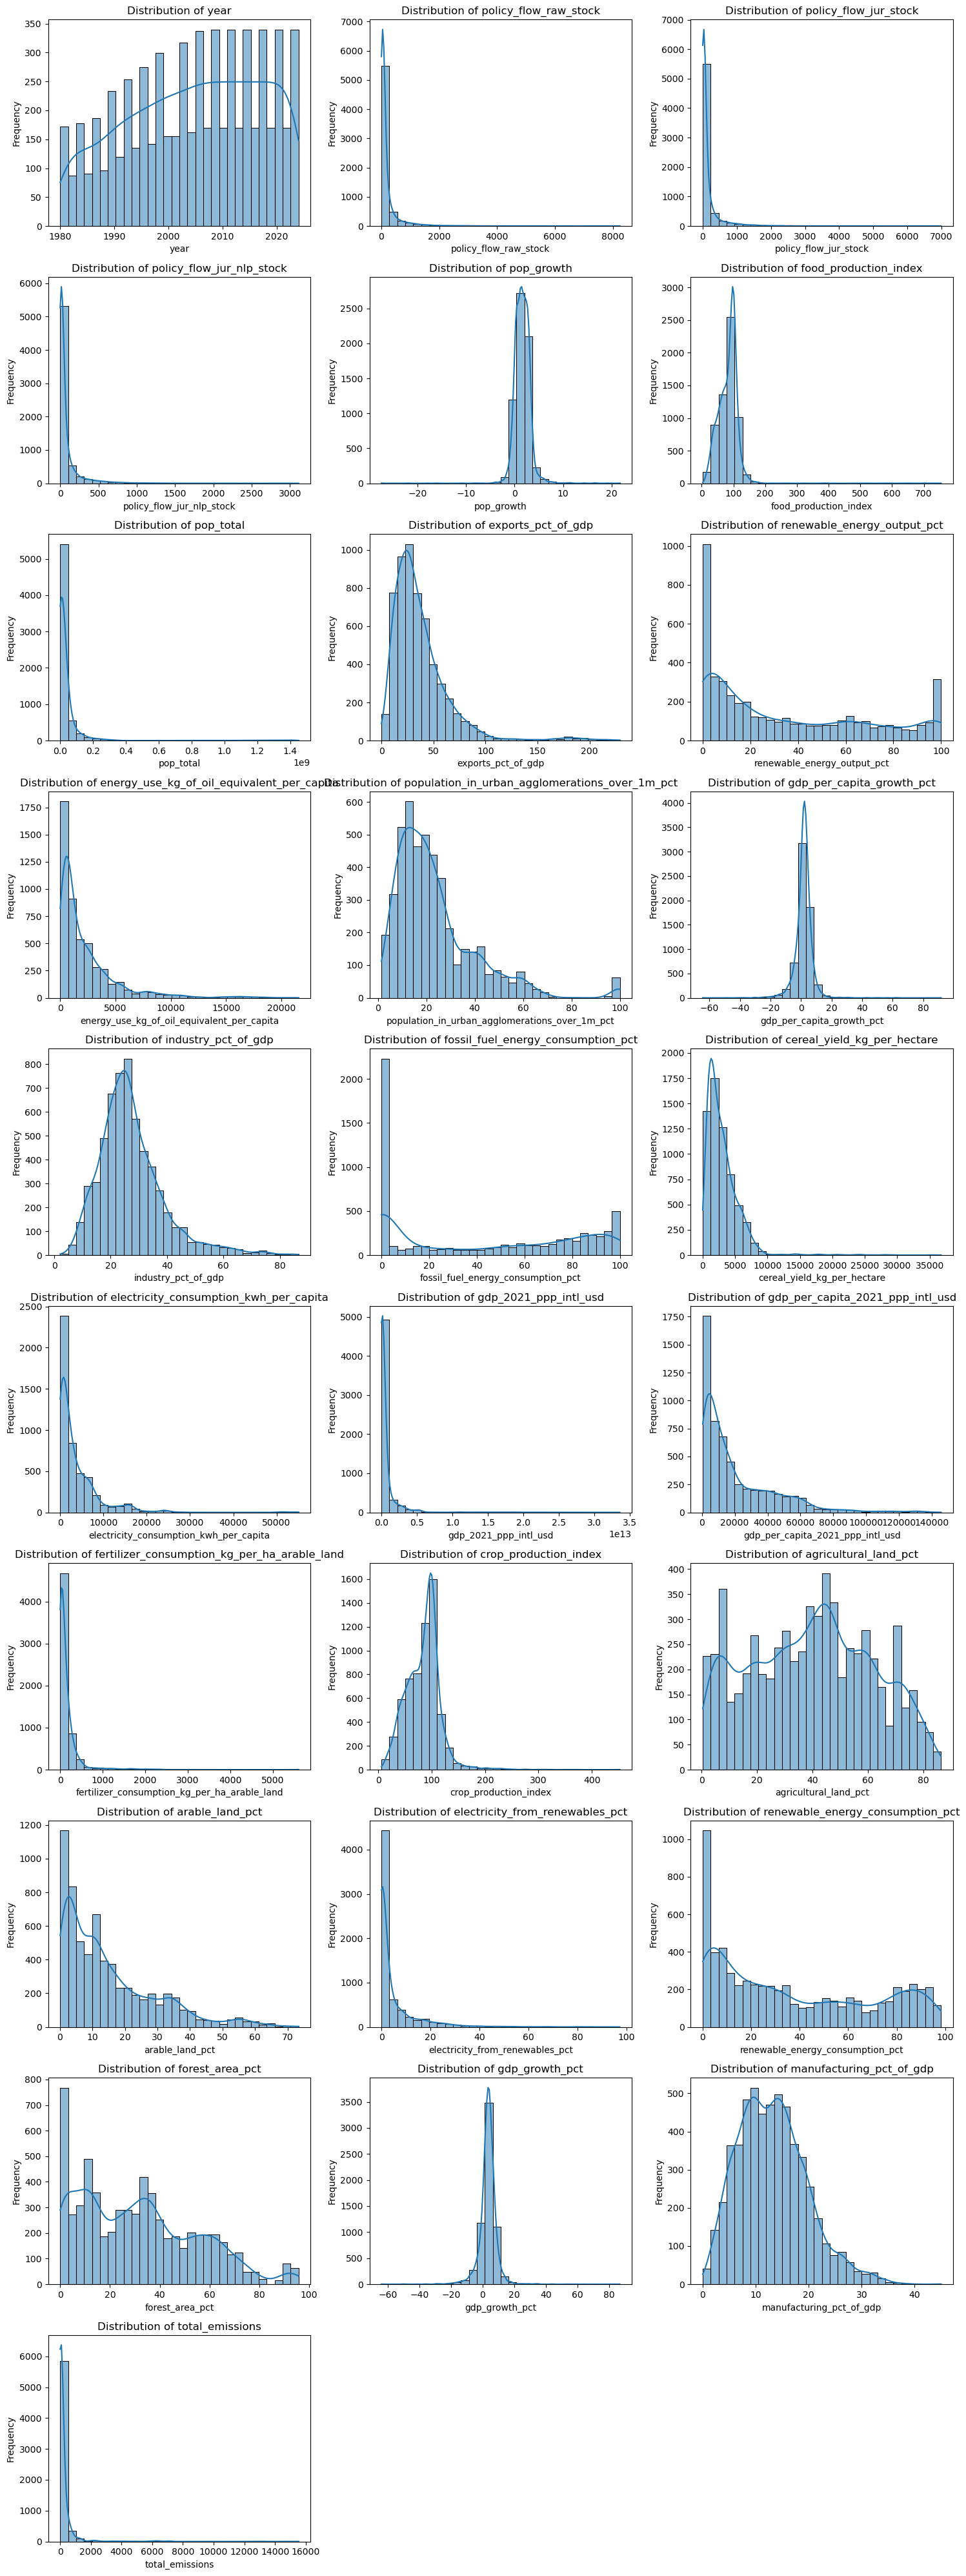

In [33]:
eda_utils.plot_numeric_fields_distributions(training_df)

In [34]:
training_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6454 entries, 0 to 6453
Data columns (total 29 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   iso_alpha_3                                     6454 non-null   object 
 1   year                                            6454 non-null   int64  
 2   policy_flow_raw_stock                           6454 non-null   int64  
 3   policy_flow_jur_stock                           6454 non-null   float64
 4   policy_flow_jur_nlp_stock                       6454 non-null   float64
 5   pop_growth                                      6452 non-null   float64
 6   food_production_index                           6183 non-null   float64
 7   pop_total                                       6454 non-null   float64
 8   exports_pct_of_gdp                              5768 non-null   float64
 9   renewable_energy_output_pct              

### Check correlation and skewness

In [35]:
target = "total_emissions"
features = [
    c for c in training_df.columns
    if c not in ["iso_alpha_3", "year", target]
]


In [36]:
def within_country_corr(df, features, target):
    out = []

    for country, g in df.groupby("iso_alpha_3"):
        if g[target].notna().sum() < 5:
            continue  # too few observations

        for f in features:
            valid = g[[f, target]].dropna()
            if len(valid) < 5:
                continue

            corr = valid[f].corr(valid[target])
            out.append({
                "iso_alpha_3": country,
                "feature": f,
                "corr": corr
            })

    return pd.DataFrame(out)


In [37]:
corr_df = within_country_corr(
    training_df, features, target
)

corr_summary = (
    corr_df
    .groupby("feature")["corr"]
    .agg(
        median_corr="median",
        mean_corr="mean",
        abs_median_corr=lambda x: np.median(np.abs(x)),
        n_countries="count"
    )
    .sort_values("abs_median_corr", ascending=False)
)


/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encount

In [38]:
corr_summary

,median_corr,mean_corr,abs_median_corr,n_countries
feature,,,,
pop_total,0.905715,0.538821,0.921454,170
gdp_2021_ppp_intl_usd,0.895285,0.562564,0.906433,167
policy_flow_raw_stock,0.841633,0.458384,0.876378,170
policy_flow_jur_nlp_stock,0.843669,0.455849,0.874783,170
policy_flow_jur_stock,0.837579,0.452625,0.867958,170
energy_use_kg_of_oil_equivalent_per_capita,0.851058,0.618007,0.862014,160
population_in_urban_agglomerations_over_1m_pct,0.688169,0.372786,0.835293,116
gdp_per_capita_2021_ppp_intl_usd,0.787637,0.456425,0.812143,167
food_production_index,0.802484,0.562256,0.803279,170


### Check Skewness

In [39]:
def within_country_skew(df, features):
    out = []

    for country, g in df.groupby("iso_alpha_3"):
        for f in features:
            x = g[f].dropna()
            if len(x) < 5:
                continue

            out.append({
                "iso_alpha_3": country,
                "feature": f,
                "skewness": skew(x)
            })

    return pd.DataFrame(out)


In [40]:
skew_df = within_country_skew(
    training_df, features
)

skew_summary = (
    skew_df
    .groupby("feature")["skewness"]
    .agg(
        median_skew="median",
        mean_skew="mean",
        abs_median_skew=lambda x: np.median(np.abs(x)),
        n_countries="count"
    )
    .sort_values("abs_median_skew", ascending=False)
)


/var/folders/tc/7lgly1g56n1cclb6ls7rcwzr0000gn/T/ipykernel_80697/2906196379.py:13: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  "skewness": skew(x)


In [41]:
corr_summary_renamed = corr_summary.rename(
    columns={"n_countries": "n_countries_corr"}
)

skew_summary_renamed = skew_summary.rename(
    columns={"n_countries": "n_countries_skew"}
)

diagnostics = (
    corr_summary_renamed
    .join(skew_summary_renamed, how="inner")
    .sort_values(
        ["abs_median_corr", "abs_median_skew"],
        ascending=False
    )
)

diagnostics

,median_corr,mean_corr,abs_median_corr,n_countries_corr,median_skew,mean_skew,abs_median_skew,n_countries_skew
feature,,,,,,,,
pop_total,0.905715,0.538821,0.921454,170,0.082130,0.077611,0.320130,170
gdp_2021_ppp_intl_usd,0.895285,0.562564,0.906433,167,0.255611,0.250006,0.324541,167
policy_flow_raw_stock,0.841633,0.458384,0.876378,170,0.960675,0.950596,0.960675,170
policy_flow_jur_nlp_stock,0.843669,0.455849,0.874783,170,0.945313,0.947800,0.945313,170
policy_flow_jur_stock,0.837579,0.452625,0.867958,170,1.017626,1.012919,1.017626,170
energy_use_kg_of_oil_equivalent_per_capita,0.851058,0.618007,0.862014,160,0.008486,-0.006338,0.402662,160
population_in_urban_agglomerations_over_1m_pct,0.688169,0.372786,0.835293,116,0.043852,0.004200,0.423003,116
gdp_per_capita_2021_ppp_intl_usd,0.787637,0.456425,0.812143,167,0.125860,0.135845,0.343551,167
food_production_index,0.802484,0.562256,0.803279,170,0.258832,0.196061,0.421477,170


## Feature Engineering for Numeric Features

In [42]:
log_vars = [
    "pop_total",
    "gdp_2021_ppp_intl_usd",
    "gdp_per_capita_2021_ppp_intl_usd",
    "energy_use_kg_of_oil_equivalent_per_capita",
    "electricity_consumption_kwh_per_capita",
]
policy_vars = [
    "policy_flow_raw_stock",
    "policy_flow_jur_stock",
    "policy_flow_jur_nlp_stock",
]
share_vars = [
    "fossil_fuel_energy_consumption_pct",
    "renewable_energy_consumption_pct",
    "electricity_from_renewables_pct",
    "population_in_urban_agglomerations_over_1m_pct",
    "industry_pct_of_gdp",
    "manufacturing_pct_of_gdp",
    "exports_pct_of_gdp",
    "renewable_energy_output_pct"
]
agri_log_vars = [
    "cereal_yield_kg_per_hectare",
    "fertilizer_consumption_kg_per_ha_arable_land",
]

agri_level_vars = [
    "food_production_index",
    "crop_production_index",
    "agricultural_land_pct",
    "arable_land_pct",
    "forest_area_pct",
]
growth_vars = [
    "gdp_growth_pct",
    "gdp_per_capita_growth_pct",
    "pop_growth",
]


In [43]:
training_df_transformed = training_df.copy()

In [44]:
# apply log transformation
for v in log_vars + policy_vars + agri_log_vars:
    training_df_transformed[f"log_{v}"] = np.log1p(training_df_transformed[v])


In [45]:
# Clip share 
bounded_vars = share_vars + agri_level_vars

training_df_transformed[bounded_vars] = (
    training_df_transformed[bounded_vars]
        .clip(lower=0, upper=100)
)


In [46]:
training_df_transformed.columns

Index(['iso_alpha_3', 'year', 'policy_flow_raw_stock', 'policy_flow_jur_stock',
       'policy_flow_jur_nlp_stock', 'pop_growth', 'food_production_index',
       'pop_total', 'exports_pct_of_gdp', 'renewable_energy_output_pct',
       'energy_use_kg_of_oil_equivalent_per_capita',
       'population_in_urban_agglomerations_over_1m_pct',
       'gdp_per_capita_growth_pct', 'industry_pct_of_gdp',
       'fossil_fuel_energy_consumption_pct', 'cereal_yield_kg_per_hectare',
       'electricity_consumption_kwh_per_capita', 'gdp_2021_ppp_intl_usd',
       'gdp_per_capita_2021_ppp_intl_usd',
       'fertilizer_consumption_kg_per_ha_arable_land', 'crop_production_index',
       'agricultural_land_pct', 'arable_land_pct',
       'electricity_from_renewables_pct', 'renewable_energy_consumption_pct',
       'forest_area_pct', 'gdp_growth_pct', 'manufacturing_pct_of_gdp',
       'total_emissions', 'log_pop_total', 'log_gdp_2021_ppp_intl_usd',
       'log_gdp_per_capita_2021_ppp_intl_usd',
       'lo

In [47]:
final_features = (
    [f"log_{v}" for v in log_vars] +
    [f"log_{v}" for v in policy_vars] +
    [f"log_{v}" for v in agri_log_vars] +
    share_vars +
    agri_level_vars +
    growth_vars
)

target = ["total_emissions"]
fixed_effect = ["iso_alpha_3"]
time_var = ["year"]

fields_to_keep = fixed_effect + time_var + final_features + target

In [48]:
# Assert physical plausibility (ignore NaNs)
for col in bounded_vars:
    assert training_df_transformed[col].dropna().min() >= 0, f"Negative values in {col}"
    assert training_df_transformed[col].dropna().max() <= 100, f"Values >100 in {col}"


In [49]:
# No infinite logs
assert np.isfinite(training_df_transformed[final_features].dropna()).all().all()


In [50]:
# Feature availability
training_df_transformed[final_features].isna().mean().sort_values(ascending=False)

renewable_energy_output_pct                         0.284785
population_in_urban_agglomerations_over_1m_pct      0.275488
log_electricity_consumption_kwh_per_capita          0.255036
log_energy_use_kg_of_oil_equivalent_per_capita      0.226836
manufacturing_pct_of_gdp                            0.135110
log_gdp_per_capita_2021_ppp_intl_usd                0.127673
log_gdp_2021_ppp_intl_usd                           0.127673
exports_pct_of_gdp                                  0.106291
industry_pct_of_gdp                                 0.078866
log_fertilizer_consumption_kg_per_ha_arable_land    0.065541
fossil_fuel_energy_consumption_pct                  0.061047
crop_production_index                               0.041989
food_production_index                               0.041989
log_cereal_yield_kg_per_hectare                     0.024481
gdp_growth_pct                                      0.008832
gdp_per_capita_growth_pct                           0.008832
forest_area_pct         

In [51]:
training_df_transformed = training_df_transformed[fields_to_keep]

In [52]:
# create log target (idempotent)
training_df_transformed["log_total_emissions"] = np.log1p(training_df_transformed["total_emissions"])

In [53]:
print(training_df_transformed["log_total_emissions"].max())
print(training_df_transformed["log_total_emissions"].min())

9.650987386689062
0.025868037800097013


In [54]:
# drop renewable_energy_output_pct due to high missingness
training_df_transformed = training_df_transformed.drop(
    columns=["renewable_energy_output_pct", "total_emissions"],
    errors="ignore"
)


In [55]:
training_df_transformed.columns

Index(['iso_alpha_3', 'year', 'log_pop_total', 'log_gdp_2021_ppp_intl_usd',
       'log_gdp_per_capita_2021_ppp_intl_usd',
       'log_energy_use_kg_of_oil_equivalent_per_capita',
       'log_electricity_consumption_kwh_per_capita',
       'log_policy_flow_raw_stock', 'log_policy_flow_jur_stock',
       'log_policy_flow_jur_nlp_stock', 'log_cereal_yield_kg_per_hectare',
       'log_fertilizer_consumption_kg_per_ha_arable_land',
       'fossil_fuel_energy_consumption_pct',
       'renewable_energy_consumption_pct', 'electricity_from_renewables_pct',
       'population_in_urban_agglomerations_over_1m_pct', 'industry_pct_of_gdp',
       'manufacturing_pct_of_gdp', 'exports_pct_of_gdp',
       'food_production_index', 'crop_production_index',
       'agricultural_land_pct', 'arable_land_pct', 'forest_area_pct',
       'gdp_growth_pct', 'gdp_per_capita_growth_pct', 'pop_growth',
       'log_total_emissions'],
      dtype='object')

## EDA 2

In [56]:
target = "log_total_emissions"
features = [
    c for c in training_df_transformed.columns
    if c not in ["iso_alpha_3", "year", target]
]

corr_df = within_country_corr(
    training_df_transformed, features, target
)

corr_summary = (
    corr_df
    .groupby("feature")["corr"]
    .agg(
        median_corr="median",
        mean_corr="mean",
        abs_median_corr=lambda x: np.median(np.abs(x)),
        n_countries="count"
    )
    .sort_values("abs_median_corr", ascending=False)
)



skew_df = within_country_skew(
    training_df_transformed, features
)

skew_summary = (
    skew_df
    .groupby("feature")["skewness"]
    .agg(
        median_skew="median",
        mean_skew="mean",
        abs_median_skew=lambda x: np.median(np.abs(x)),
        n_countries="count"
    )
    .sort_values("abs_median_skew", ascending=False)
)

corr_summary_renamed = corr_summary.rename(
    columns={"n_countries": "n_countries_corr"}
)

skew_summary_renamed = skew_summary.rename(
    columns={"n_countries": "n_countries_skew"}
)

diagnostics = (
    corr_summary_renamed
    .join(skew_summary_renamed, how="inner")
    .sort_values(
        ["abs_median_corr", "abs_median_skew"],
        ascending=False
    )
)

diagnostics

/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encount

,median_corr,mean_corr,abs_median_corr,n_countries_corr,median_skew,mean_skew,abs_median_skew,n_countries_skew
feature,,,,,,,,
log_policy_flow_jur_stock,0.906946,0.527351,0.914946,170,-0.205667,-0.236513,0.303945,170
log_pop_total,0.901189,0.544774,0.914094,170,-0.128987,-0.137422,0.239863,170
log_policy_flow_jur_nlp_stock,0.907028,0.525385,0.913202,170,-0.219429,-0.224726,0.292718,170
log_policy_flow_raw_stock,0.907549,0.526121,0.910941,170,-0.221776,-0.293314,0.307527,170
log_gdp_2021_ppp_intl_usd,0.897244,0.574556,0.900735,167,-0.114734,-0.118789,0.238357,167
log_energy_use_kg_of_oil_equivalent_per_capita,0.845516,0.614240,0.865094,160,-0.154657,-0.213837,0.393541,160
population_in_urban_agglomerations_over_1m_pct,0.730387,0.375519,0.837992,116,0.043852,0.004200,0.423003,116
log_gdp_per_capita_2021_ppp_intl_usd,0.773290,0.462825,0.816777,167,-0.130379,-0.123374,0.336451,167
food_production_index,0.809286,0.567144,0.809286,170,-0.202908,-0.482967,0.431048,170


## ML

In [57]:
training_df_transformed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6454 entries, 0 to 6453
Data columns (total 28 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   iso_alpha_3                                       6454 non-null   object 
 1   year                                              6454 non-null   int64  
 2   log_pop_total                                     6454 non-null   float64
 3   log_gdp_2021_ppp_intl_usd                         5630 non-null   float64
 4   log_gdp_per_capita_2021_ppp_intl_usd              5630 non-null   float64
 5   log_energy_use_kg_of_oil_equivalent_per_capita    4990 non-null   float64
 6   log_electricity_consumption_kwh_per_capita        4808 non-null   float64
 7   log_policy_flow_raw_stock                         6454 non-null   float64
 8   log_policy_flow_jur_stock                         6454 non-null   float64
 9   log_policy_flow_jur

In [58]:
# Make sure the df is sorted by iso_alpha_3 and year
training_df_transformed = training_df_transformed.sort_values(by=["iso_alpha_3", "year"]).reset_index(drop=True)

In [59]:
training_df_transformed[features].isna().mean().sort_values(ascending=False).head()


population_in_urban_agglomerations_over_1m_pct    0.275488
log_electricity_consumption_kwh_per_capita        0.255036
log_energy_use_kg_of_oil_equivalent_per_capita    0.226836
manufacturing_pct_of_gdp                          0.135110
log_gdp_2021_ppp_intl_usd                         0.127673
dtype: float64

In [60]:
training_df_transformed["log_total_emissions"].describe()

count    6454.000000
mean        3.725789
std         1.813781
min         0.025868
25%         2.522739
50%         3.651676
75%         4.876096
max         9.650987
Name: log_total_emissions, dtype: float64

In [61]:
training_df["year"].min(), training_df["year"].max()

(np.int64(1980), np.int64(2024))

In [62]:
xgb_params = dict(
    n_estimators=300,      # Enough trees, not excessive for this size
    max_depth=6,           # Controls overfitting, 4–6 is common
    learning_rate=0.07,    # Slower learning, safer default than 0.1
    subsample=0.8,         # Row sampling for robustness
    colsample_bytree=0.8,  # Feature sampling per tree for robustness
    reg_alpha=0.2,         # L1 regularization, good for tabular data
    reg_lambda=1.0,        # L2 regularization (default 1.0, safe)
    random_state=42,       # For reproducibility
    n_jobs=-1,             # Use all cores
    verbosity=0
)

print("Running regression without group feature...")

ra = RegressionAnalysis(
    df=training_df_transformed,
    target_col="log_total_emissions",
    group_col="iso_alpha_3",
    year_col="year",
    holdout_years=6,
    xgb_params=xgb_params,
    scaler_type="minmax",
    feature_cols=features
)

ra.cross_validate()
ra.fit()
ra.evaluate()

Running regression without group feature...

Cross-validation results:
------------------------------------------------------------------------------------------
Model               Time MAE    Group MAE


/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/miniconda3/envs/etpe_env/lib/py

ElasticNet            0.4302          nan
RandomForest          0.5159       0.4270
XGBoost               0.4726       0.3847
Median                1.4459       1.4586

Holdout evaluation:
------------------------------------------------------------------------------------------------------------------------
Model          Train MAE (log) Test MAE (log)  Train RMSE (log)   Test RMSE (log)   Train MAE (level)    Test MAE (level)
------------------------------------------------------------------------------------------------------------------------
ElasticNet              0.3081         0.2758            0.3778            0.3426               67.06               89.91
RandomForest            0.0193         0.1887            0.0326            0.3075                4.75               61.99
XGBoost                 0.0273         0.1513            0.0370            0.2135                5.98               70.66
Median                  1.4439         1.4140            1.8178            1.8311

{'ElasticNet': {'train_mae_log': 0.30813600268499,
  'test_mae_log': 0.2757924628879529,
  'train_rmse_log': np.float64(0.3778382946646419),
  'test_rmse_log': np.float64(0.3426263608953225),
  'train_mae_level': np.float64(67.05682267717587),
  'test_mae_level': np.float64(89.9085800097481)},
 'RandomForest': {'train_mae_log': 0.019287455241812194,
  'test_mae_log': 0.18873022856800165,
  'train_rmse_log': np.float64(0.03264294069170523),
  'test_rmse_log': np.float64(0.3075455567800343),
  'train_mae_level': np.float64(4.745649336719589),
  'test_mae_level': np.float64(61.98819775911881)},
 'XGBoost': {'train_mae_log': 0.027288406322294147,
  'test_mae_log': 0.15132890293381313,
  'train_rmse_log': np.float64(0.037005254903146385),
  'test_rmse_log': np.float64(0.21348279237670714),
  'train_mae_level': np.float64(5.984501233237888),
  'test_mae_level': np.float64(70.66240919156917)},
 'Median': {'train_mae_log': 1.4438812902216733,
  'test_mae_log': 1.4139626705005595,
  'train_rmse

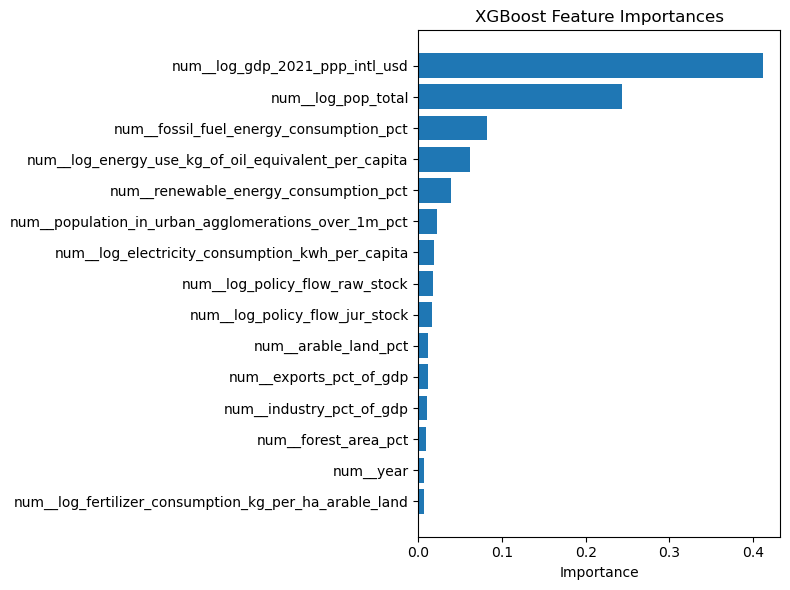

In [63]:
ra.plot_feature_importances(model="XGBoost", top_n=15)

In [64]:
# Table
country_errors = ra.per_country_errors(model="XGBoost")
country_errors.sort_values(by="mae_level", ascending=False)


,iso_alpha_3,n_obs,mae_log,rmse_log,mae_level
168,CHN,6,0.586790,0.611008,6510.300535
169,IDN,6,0.895817,0.898503,1669.701302
66,USA,6,0.084173,0.087363,480.355950
163,MEX,6,0.403932,0.470523,362.188434
53,IND,6,0.072037,0.083371,259.797048
...,...,...,...,...,...
50,KIR,6,0.067938,0.116552,0.083914
30,VUT,6,0.046576,0.052533,0.074229
24,VCT,6,0.043398,0.049256,0.052566
11,GRD,6,0.032981,0.042189,0.039285


In [65]:


# # Plot
# ra.plot_per_country_errors(model="XGBoost", metric="mae_log", top_k=25)
# ra.plot_per_country_errors(model="XGBoost", metric="mae_level", top_k=25)


In [66]:
# Table
policy_country = ra.policy_effect_by_country(model="XGBoost")
policy_country

,iso_alpha_3,mean_delta_log,mean_delta_level,median_delta_level,n_obs
0,PNG,-0.132393,-2.115345,-2.114192,6
1,MEX,-0.099570,-108.346527,-108.946655,6
2,ROU,-0.088569,-13.288949,-15.914524,6
3,IRN,-0.086838,-79.080833,-68.524323,6
4,EGY,-0.068070,-30.446457,-25.331406,6
...,...,...,...,...,...
165,SVN,0.461750,8.731465,8.546587,6
166,KGZ,0.467535,8.511728,8.431030,6
167,PRY,0.524405,15.753151,15.707884,6
168,QAT,0.571015,62.012310,62.085918,6


In [67]:
# # Table
# policy_country = ra.policy_effect_by_country(model="XGBoost")
# policy_country.head()

# # Plot
# ra.plot_policy_effects(model="XGBoost", top_k=25)


### Retraining 15 features

In [68]:
def clean_feature_name(name):
    return name.replace("num__", "").replace("cat__", "")
top_15_preds = [f"{clean_feature_name(f)}" for f in ra.top_n_features("XGBoost", 15)]
top_15_preds


['log_gdp_2021_ppp_intl_usd',
 'log_pop_total',
 'fossil_fuel_energy_consumption_pct',
 'log_energy_use_kg_of_oil_equivalent_per_capita',
 'renewable_energy_consumption_pct',
 'population_in_urban_agglomerations_over_1m_pct',
 'log_electricity_consumption_kwh_per_capita',
 'log_policy_flow_raw_stock',
 'log_policy_flow_jur_stock',
 'arable_land_pct',
 'exports_pct_of_gdp',
 'industry_pct_of_gdp',
 'forest_area_pct',
 'year',
 'log_fertilizer_consumption_kg_per_ha_arable_land']

In [69]:
retraining_fields_top15 = fixed_effect + top_15_preds  + [target]
retraining_fields_top15


['iso_alpha_3',
 'log_gdp_2021_ppp_intl_usd',
 'log_pop_total',
 'fossil_fuel_energy_consumption_pct',
 'log_energy_use_kg_of_oil_equivalent_per_capita',
 'renewable_energy_consumption_pct',
 'population_in_urban_agglomerations_over_1m_pct',
 'log_electricity_consumption_kwh_per_capita',
 'log_policy_flow_raw_stock',
 'log_policy_flow_jur_stock',
 'arable_land_pct',
 'exports_pct_of_gdp',
 'industry_pct_of_gdp',
 'forest_area_pct',
 'year',
 'log_fertilizer_consumption_kg_per_ha_arable_land',
 'log_total_emissions']

In [70]:
retraining_df_top15_preds = training_df_transformed[retraining_fields_top15].copy()
retraining_df_top15_preds = retraining_df_top15_preds.drop(columns=["log_policy_flow_raw_stock"])
# remove log_policy_flow_raw_stock from top_15_preds
top_15_preds.remove("log_policy_flow_raw_stock")

retraining_df_top15_preds.head()

,iso_alpha_3,log_gdp_2021_ppp_intl_usd,log_pop_total,fossil_fuel_energy_consumption_pct,log_energy_use_kg_of_oil_equivalent_per_capita,renewable_energy_consumption_pct,population_in_urban_agglomerations_over_1m_pct,log_electricity_consumption_kwh_per_capita,log_policy_flow_jur_stock,arable_land_pct,exports_pct_of_gdp,industry_pct_of_gdp,forest_area_pct,year,log_fertilizer_consumption_kg_per_ha_arable_land,log_total_emissions
0,AGO,NaN,15.911548,25.476352,NaN,72.3,9.483171,NaN,1.252763,2.326141,NaN,NaN,63.57807,1980,1.915908,3.307180
1,AGO,NaN,15.947972,25.476352,NaN,72.3,9.619106,NaN,1.321756,2.326141,NaN,NaN,63.57807,1981,1.643339,3.254307
2,AGO,NaN,15.984753,25.476352,NaN,72.3,9.754209,NaN,1.386294,2.326141,NaN,NaN,63.57807,1982,1.002152,3.342043
3,AGO,NaN,16.021913,25.476352,NaN,72.3,9.887985,NaN,1.446919,2.326141,NaN,NaN,63.57807,1983,1.377636,3.396239
4,AGO,NaN,16.058974,25.476352,NaN,72.3,10.227886,NaN,1.504077,2.326141,NaN,NaN,63.57807,1984,1.226915,3.410605


In [71]:
xgb_params = dict(
    n_estimators=300,      # Enough trees, not excessive for this size
    max_depth=6,           # Controls overfitting, 4–6 is common
    learning_rate=0.07,    # Slower learning, safer default than 0.1
    subsample=0.8,         # Row sampling for robustness
    colsample_bytree=0.8,  # Feature sampling per tree for robustness
    reg_alpha=0.2,         # L1 regularization, good for tabular data
    reg_lambda=1.0,        # L2 regularization (default 1.0, safe)
    random_state=42,       # For reproducibility
    n_jobs=-1,             # Use all cores
    verbosity=0
)

print("Running regression without group feature...")

ra_15_feat = RegressionAnalysis(
    df=retraining_df_top15_preds,
    target_col="log_total_emissions",
    group_col="iso_alpha_3",
    year_col="year",
    holdout_years=6,
    xgb_params=xgb_params,
    scaler_type="minmax",
    feature_cols=top_15_preds
)

ra_15_feat.cross_validate()
ra_15_feat.fit()
ra_15_feat.evaluate()

Running regression without group feature...

Cross-validation results:
------------------------------------------------------------------------------------------
Model               Time MAE    Group MAE


/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/miniconda3/envs/etpe_env/lib/py

ElasticNet            0.4283          nan
RandomForest          0.5163       0.4138
XGBoost               0.4657       0.3902
Median                1.4459       1.4586

Holdout evaluation:
------------------------------------------------------------------------------------------------------------------------
Model          Train MAE (log) Test MAE (log)  Train RMSE (log)   Test RMSE (log)   Train MAE (level)    Test MAE (level)
------------------------------------------------------------------------------------------------------------------------
ElasticNet              0.3086         0.2753            0.3780            0.3425               66.61               89.50
RandomForest            0.0181         0.1863            0.0310            0.3058                3.95               61.71
XGBoost                 0.0307         0.1506            0.0416            0.2129                6.33               55.51
Median                  1.4439         1.4140            1.8178            1.8311

{'ElasticNet': {'train_mae_log': 0.3086014029886236,
  'test_mae_log': 0.2753194602439473,
  'train_rmse_log': np.float64(0.37804374181929634),
  'test_rmse_log': np.float64(0.34249143213175914),
  'train_mae_level': np.float64(66.60848991421678),
  'test_mae_level': np.float64(89.50489959284232)},
 'RandomForest': {'train_mae_log': 0.018083572569863912,
  'test_mae_log': 0.18631374152896704,
  'train_rmse_log': np.float64(0.030954711593916495),
  'test_rmse_log': np.float64(0.3057737255307834),
  'train_mae_level': np.float64(3.9458786936207564),
  'test_mae_level': np.float64(61.705637825086036)},
 'XGBoost': {'train_mae_log': 0.03073635497933527,
  'test_mae_log': 0.15062552766672258,
  'train_rmse_log': np.float64(0.04163519050944404),
  'test_rmse_log': np.float64(0.2128955891141786),
  'train_mae_level': np.float64(6.331622357433248),
  'test_mae_level': np.float64(55.51466326753568)},
 'Median': {'train_mae_log': 1.4438812902216733,
  'test_mae_log': 1.4139626705005595,
  'train

In [72]:
# Table
country_errors_15_feat = ra_15_feat.per_country_errors(model="XGBoost")
country_errors_15_feat.sort_values(by="mae_level", ascending=False)


,iso_alpha_3,n_obs,mae_log,rmse_log,mae_level
166,CHN,6,0.439271,0.457315,5237.743488
150,IDN,6,0.285468,0.291332,388.040230
71,IND,6,0.088796,0.142669,295.983574
164,FRA,6,0.410754,0.449872,214.915655
157,GBR,6,0.362427,0.453063,199.290338
...,...,...,...,...,...
4,COM,6,0.025702,0.028896,0.048095
5,ATG,6,0.026582,0.028319,0.037272
6,GRD,6,0.026926,0.029278,0.032719
1,DMA,6,0.020005,0.022198,0.023250


In [73]:
# Table
policy_country_15_feat = ra_15_feat.policy_effect_by_country(model="XGBoost")
policy_country_15_feat

,iso_alpha_3,mean_delta_log,mean_delta_level,median_delta_level,n_obs
0,MEX,-0.247361,-244.388306,-259.586914,6
1,AGO,-0.242280,-23.318216,-24.863400,6
2,PER,-0.241337,-36.714035,-41.873627,6
3,SWE,-0.238600,-17.450842,-17.470383,6
4,IDN,-0.212332,-346.934906,-345.795776,6
...,...,...,...,...,...
165,KGZ,0.438950,7.935641,8.184551,6
166,CUB,0.446245,13.453923,12.861809,6
167,BFA,0.456342,9.950953,9.764059,6
168,BEN,0.458267,7.548234,7.534697,6


### Retrain 10 features

In [74]:
def clean_feature_name(name):
    return name.replace("num__", "").replace("cat__", "")
top_10_preds = [f"{clean_feature_name(f)}" for f in ra.top_n_features("XGBoost", 10)]
top_10_preds

['log_gdp_2021_ppp_intl_usd',
 'log_pop_total',
 'fossil_fuel_energy_consumption_pct',
 'log_energy_use_kg_of_oil_equivalent_per_capita',
 'renewable_energy_consumption_pct',
 'population_in_urban_agglomerations_over_1m_pct',
 'log_electricity_consumption_kwh_per_capita',
 'log_policy_flow_raw_stock',
 'log_policy_flow_jur_stock',
 'arable_land_pct']

In [75]:
retraining_fields_top10 = fixed_effect + time_var + top_10_preds  + [target]
retraining_fields_top10

['iso_alpha_3',
 'year',
 'log_gdp_2021_ppp_intl_usd',
 'log_pop_total',
 'fossil_fuel_energy_consumption_pct',
 'log_energy_use_kg_of_oil_equivalent_per_capita',
 'renewable_energy_consumption_pct',
 'population_in_urban_agglomerations_over_1m_pct',
 'log_electricity_consumption_kwh_per_capita',
 'log_policy_flow_raw_stock',
 'log_policy_flow_jur_stock',
 'arable_land_pct',
 'log_total_emissions']

In [76]:
retraining_df_top10_preds = training_df_transformed[retraining_fields_top10].copy()
retraining_df_top10_preds.head()

,iso_alpha_3,year,log_gdp_2021_ppp_intl_usd,log_pop_total,fossil_fuel_energy_consumption_pct,log_energy_use_kg_of_oil_equivalent_per_capita,renewable_energy_consumption_pct,population_in_urban_agglomerations_over_1m_pct,log_electricity_consumption_kwh_per_capita,log_policy_flow_raw_stock,log_policy_flow_jur_stock,arable_land_pct,log_total_emissions
0,AGO,1980,NaN,15.911548,25.476352,NaN,72.3,9.483171,NaN,2.397895,1.252763,2.326141,3.307180
1,AGO,1981,NaN,15.947972,25.476352,NaN,72.3,9.619106,NaN,2.484907,1.321756,2.326141,3.254307
2,AGO,1982,NaN,15.984753,25.476352,NaN,72.3,9.754209,NaN,2.564949,1.386294,2.326141,3.342043
3,AGO,1983,NaN,16.021913,25.476352,NaN,72.3,9.887985,NaN,2.639057,1.446919,2.326141,3.396239
4,AGO,1984,NaN,16.058974,25.476352,NaN,72.3,10.227886,NaN,2.708050,1.504077,2.326141,3.410605


In [77]:
xgb_params = dict(
    n_estimators=300,      # Enough trees, not excessive for this size
    max_depth=6,           # Controls overfitting, 4–6 is common
    learning_rate=0.07,    # Slower learning, safer default than 0.1
    subsample=0.8,         # Row sampling for robustness
    colsample_bytree=0.8,  # Feature sampling per tree for robustness
    reg_alpha=0.2,         # L1 regularization, good for tabular data
    reg_lambda=1.0,        # L2 regularization (default 1.0, safe)
    random_state=42,       # For reproducibility
    n_jobs=-1,             # Use all cores
    verbosity=0
)

print("Running regression without group feature...")

ra_10_feat = RegressionAnalysis(
    df=retraining_df_top10_preds,
    target_col="log_total_emissions",
    group_col="iso_alpha_3",
    year_col="year",
    holdout_years=6,
    xgb_params=xgb_params,
    scaler_type="minmax",
    feature_cols=top_10_preds
)

ra_10_feat.cross_validate()
ra_10_feat.fit()
ra_10_feat.evaluate()

Running regression without group feature...

Cross-validation results:
------------------------------------------------------------------------------------------
Model               Time MAE    Group MAE


/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/miniconda3/envs/etpe_env/lib/py

ElasticNet            0.4391          nan
RandomForest          0.5152       0.3984
XGBoost               0.4365       0.3807
Median                1.4459       1.4586

Holdout evaluation:
------------------------------------------------------------------------------------------------------------------------
Model          Train MAE (log) Test MAE (log)  Train RMSE (log)   Test RMSE (log)   Train MAE (level)    Test MAE (level)
------------------------------------------------------------------------------------------------------------------------
ElasticNet              0.3255         0.2988            0.3995            0.3676               68.85               92.06
RandomForest            0.0180         0.1780            0.0311            0.2852                3.86               52.30
XGBoost                 0.0354         0.1591            0.0478            0.2201                7.67               64.13
Median                  1.4439         1.4140            1.8178            1.8311

{'ElasticNet': {'train_mae_log': 0.3254520767091887,
  'test_mae_log': 0.2988061775566714,
  'train_rmse_log': np.float64(0.39950296896946486),
  'test_rmse_log': np.float64(0.3676268303912808),
  'train_mae_level': np.float64(68.84811589321764),
  'test_mae_level': np.float64(92.05744525177403)},
 'RandomForest': {'train_mae_log': 0.018016090303767756,
  'test_mae_log': 0.17802108010589046,
  'train_rmse_log': np.float64(0.031099816039555014),
  'test_rmse_log': np.float64(0.2851654870404441),
  'train_mae_level': np.float64(3.85939992450111),
  'test_mae_level': np.float64(52.29740016467109)},
 'XGBoost': {'train_mae_log': 0.03537069218814968,
  'test_mae_log': 0.1591454287574898,
  'train_rmse_log': np.float64(0.04778013841713471),
  'test_rmse_log': np.float64(0.22010235182710314),
  'train_mae_level': np.float64(7.670585780900505),
  'test_mae_level': np.float64(64.13188467315163)},
 'Median': {'train_mae_log': 1.4438812902216733,
  'test_mae_log': 1.4139626705005595,
  'train_rms

In [78]:
# Table
country_errors_10_feat = ra_10_feat.per_country_errors(model="randomForest")
country_errors_10_feat.sort_values(by="mae_level", ascending=False)

,iso_alpha_3,n_obs,mae_log,rmse_log,mae_level
168,IDN,6,1.123739,1.204936,2761.824926
86,CHN,6,0.120854,0.126414,1696.844757
26,USA,6,0.043839,0.050630,265.292036
169,SGP,6,1.217724,1.367117,216.153079
156,FRA,6,0.395942,0.420958,204.498337
...,...,...,...,...,...
12,VUT,6,0.028716,0.032484,0.046306
8,BLZ,6,0.022711,0.027497,0.045590
2,COM,6,0.018919,0.023107,0.034327
4,VCT,6,0.020076,0.039230,0.024659


## Save selected model

We will keep the one trained with the top 15 features as it reduced the errors and performed better in the per-country error analysis.

In [79]:
# --------------------------------------------------
# Save the training data with predictions
# --------------------------------------------------
retraining_df_top15_preds.to_csv(
    os.path.join(TRAINING_DIR_PATH, "training_df_top15_preds.csv"),
    index=False
)

# --------------------------------------------------
# Select trained pipelines to save
# --------------------------------------------------
trained_pipelines = {
    "xgboost_top15": ra_15_feat.pipe_xgb,   # <- THIS is the key line
}

rewrite_existing_models = True

# --------------------------------------------------
# Save pipelines
# --------------------------------------------------
for name, pipeline in trained_pipelines.items():
    model_file_name = f"{name}_pipeline.pkl"
    model_path = os.path.join(MODELS_DIR_PATH, model_file_name)

    if os.path.exists(model_path) and not rewrite_existing_models:
        print(f"Model {model_file_name} already exists. Skipping save.")
        continue

    if os.path.exists(model_path):
        print(f"Overwriting existing model at {model_path}")
    else:
        print(f"Saving model to {model_path}")

    joblib.dump(pipeline, model_path)

Saving model to /Users/tony/Documents/research_project/etpe_project/ml_scripts/output/models/xgboost_top15_pipeline.pkl
